Cell 1 — Imports

In [1]:
import pandas as pd
import numpy as np
from collections import Counter

In [4]:
import os
print(os.getcwd())

c:\HTML\FL_IDS_Vehicle\notebook


Cell 2 — Load the Phase 1 Dataset

In [6]:
import pandas as pd
import numpy as np
import os
from collections import Counter

DATA_DIR = "../data_processed"

files = {
    "Benign":      "benign_sampled.csv",
    "DoS":         "dos_combined.csv",
    "DDoS":        "ddos_combined.csv",
    "Botnet":      "botnet_combined.csv",
    "BruteForce":  "bruteforce_combined.csv",
    "WebAttack":   "sqli_combined.csv",
}

label_map = {
    "Benign":     0,
    "DoS":        1,
    "DDoS":       2,
    "Botnet":     3,
    "BruteForce": 4,
    "WebAttack":  5,
}

for name, fname in files.items():
    path = os.path.join(DATA_DIR, fname)
    exists = os.path.exists(path)
    print(f"{'✓' if exists else '✗'} {name:12s} → {fname}")

✓ Benign       → benign_sampled.csv
✓ DoS          → dos_combined.csv
✓ DDoS         → ddos_combined.csv
✓ Botnet       → botnet_combined.csv
✓ BruteForce   → bruteforce_combined.csv
✓ WebAttack    → sqli_combined.csv


Cell 3 — Load Each CSV with Label Assignment
(Chunked Loading RAM cons)

In [8]:
SAMPLE_LIMITS = {
    "Benign":     300000,
    "DoS":        200000,
    "DDoS":       200000,
    "Botnet":     80000,
    "BruteForce": 60000,
    "WebAttack":  50000,
}

CHUNK_SIZE = 50000
chunks = []

for name, fname in files.items():
    path = os.path.join(DATA_DIR, fname)
    limit = SAMPLE_LIMITS[name]
    collected = []
    total_read = 0

    for chunk in pd.read_csv(path, low_memory=False, chunksize=CHUNK_SIZE, on_bad_lines="skip"):
        collected.append(chunk)
        total_read += len(chunk)
        if total_read >= limit * 2:
            break

    temp = pd.concat(collected, ignore_index=True)
    if len(temp) > limit:
        temp = temp.sample(n=limit, random_state=42)

    temp["Label"] = label_map[name]
    chunks.append(temp)
    print(f"{name:12s} → {len(temp):>7,} rows loaded")
    
    del collected, temp
    import gc
    gc.collect()

print(f"\nAll files loaded into chunks list.")

Benign       → 300,000 rows loaded
DoS          →  37,754 rows loaded
DDoS         → 200,000 rows loaded
Botnet       →  80,000 rows loaded
BruteForce   →     394 rows loaded
WebAttack    →      66 rows loaded

All files loaded into chunks list.


Cell 4 — Combine + Inspect

In [9]:
df = pd.concat(chunks, ignore_index=True)
del chunks
gc.collect()

print(f"Combined shape: {df.shape}")
print(f"\nClass distribution:")
for label, name in enumerate(["Benign", "DoS", "DDoS", "Botnet", "BruteForce", "WebAttack"]):
    count = (df["Label"] == label).sum()
    pct = count / len(df) * 100
    print(f"  Class {label} ({name:12s}): {count:>7,} rows  ({pct:.1f}%)")

print(f"\nNull values: {df.isnull().sum().sum()}")
print(f"Inf values:  {np.isinf(df.select_dtypes(include=np.number)).sum().sum()}")
print(f"\nDtypes:\n{df.dtypes.value_counts()}")

Combined shape: (618214, 324)

Class distribution:
  Class 0 (Benign      ): 300,000 rows  (48.5%)
  Class 1 (DoS         ):  37,754 rows  (6.1%)
  Class 2 (DDoS        ): 200,000 rows  (32.4%)
  Class 3 (Botnet      ):  80,000 rows  (12.9%)
  Class 4 (BruteForce  ):     394 rows  (0.1%)
  Class 5 (WebAttack   ):      66 rows  (0.0%)

Null values: 716320
Inf values:  1243257

Dtypes:
float64    259
int64       57
object       8
Name: count, dtype: int64


Cell 5 — Clean: Drop Objects, Replace Inf, Drop NaN

Cleaning happens per chunk, before concat — so we never accumulate a massive dirty DataFrame
fillna(chunk.median()) replaces Inf/NaN with the column median of that chunk — statistically safe, preserves all rows
Object columns dropped per chunk so they never enter memory as part of the big concat
SAMPLE_LIMITS updated with exact real sizes for DoS, BruteForce, WebAttack

In [11]:
import pandas as pd
import numpy as np
import gc
from collections import Counter

DATA_DIR = "../data_processed"

files = {
    "Benign":     "benign_sampled.csv",
    "DoS":        "dos_combined.csv",
    "DDoS":       "ddos_combined.csv",
    "Botnet":     "botnet_combined.csv",
    "BruteForce": "bruteforce_combined.csv",
    "WebAttack":  "sqli_combined.csv",
}

label_map = {
    "Benign":     0,
    "DoS":        1,
    "DDoS":       2,
    "Botnet":     3,
    "BruteForce": 4,
    "WebAttack":  5,
}

SAMPLE_LIMITS = {
    "Benign":     300000,
    "DoS":        37754,
    "DDoS":       200000,
    "Botnet":     80000,
    "BruteForce": 394,
    "WebAttack":  66,
}

CHUNK_SIZE = 50000
chunks = []

for name, fname in files.items():
    path = f"{DATA_DIR}/{fname}"
    limit = SAMPLE_LIMITS[name]
    collected = []
    total_read = 0

    for chunk in pd.read_csv(path, low_memory=False, chunksize=CHUNK_SIZE, on_bad_lines="skip"):
        # Drop object columns per chunk
        obj_cols = chunk.select_dtypes(include="object").columns.tolist()
        chunk.drop(columns=obj_cols, inplace=True)
        
        # Replace Inf with NaN
        chunk.replace([np.inf, -np.inf], np.nan, inplace=True)
        
        # Fill NaN with column median (per chunk)
        chunk.fillna(chunk.median(numeric_only=True), inplace=True)
        
        collected.append(chunk)
        total_read += len(chunk)
        if total_read >= limit:
            break

    temp = pd.concat(collected, ignore_index=True)
    if len(temp) > limit:
        temp = temp.sample(n=limit, random_state=42)

    temp["Label"] = label_map[name]
    chunks.append(temp)
    print(f"{name:12s} → {len(temp):>7,} rows | nulls: {temp.isnull().sum().sum()} | infs: {np.isinf(temp.select_dtypes(include=np.number)).sum().sum()}")

    del collected, temp
    gc.collect()

print("\nAll files cleaned and loaded.")

Benign       → 300,000 rows | nulls: 0 | infs: 0
DoS          →  37,754 rows | nulls: 0 | infs: 0


C:\Users\krish\AppData\Local\Temp\ipykernel_20724\2696100672.py:64: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  temp["Label"] = label_map[name]


DDoS         → 200,000 rows | nulls: 500000 | infs: 0
Botnet       →  80,000 rows | nulls: 0 | infs: 0
BruteForce   →     394 rows | nulls: 0 | infs: 0
WebAttack    →      66 rows | nulls: 0 | infs: 0

All files cleaned and loaded.


Cell 6 — Combine + Fix DDoS Nulls + Final Clean

In [12]:
df = pd.concat(chunks, ignore_index=True)
del chunks
gc.collect()

print(f"Shape before final clean: {df.shape}")
print(f"Nulls before: {df.isnull().sum().sum()}")

# Columns where median is also NaN (all-NaN columns) — drop them entirely
all_nan_cols = df.columns[df.isnull().all()].tolist()
print(f"All-NaN columns to drop: {len(all_nan_cols)}")
df.drop(columns=all_nan_cols, inplace=True)

# Fill any remaining nulls with 0 (these are columns where entire class had no valid value)
df.fillna(0, inplace=True)

# Remove infinite values that slipped through
df.replace([np.inf, -np.inf], 0, inplace=True)

print(f"Nulls after:  {df.isnull().sum().sum()}")
print(f"Infs after:   {np.isinf(df.select_dtypes(include=np.number)).sum().sum()}")
print(f"Final shape:  {df.shape}")

print(f"\nClass distribution:")
for label, name in enumerate(["Benign", "DoS", "DDoS", "Botnet", "BruteForce", "WebAttack"]):
    count = (df["Label"] == label).sum()
    pct = count / len(df) * 100
    print(f"  Class {label} ({name:12s}): {count:>7,} rows  ({pct:.1f}%)")

Shape before final clean: (618214, 318)
Nulls before: 1336428
All-NaN columns to drop: 0
Nulls after:  0
Infs after:   0
Final shape:  (618214, 318)

Class distribution:
  Class 0 (Benign      ): 300,000 rows  (48.5%)
  Class 1 (DoS         ):  37,754 rows  (6.1%)
  Class 2 (DDoS        ): 200,000 rows  (32.4%)
  Class 3 (Botnet      ):  80,000 rows  (12.9%)
  Class 4 (BruteForce  ):     394 rows  (0.1%)
  Class 5 (WebAttack   ):      66 rows  (0.0%)


618K rows, fully clean, zero nulls, zero infs, all 6 classes intact.
Now the imbalance is clear — BruteForce (394) and WebAttack (66) are dangerously small. Before SMOTE though, we do PCC feature selection first to reduce 316 features → ~80–100. Reason: running SMOTE on 316 features is slow and noisy. Reduce first, then oversample.

Cell 7 — PCC Feature Selection

In [13]:
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings("ignore")

X = df.drop(columns=["Label"])
y = df["Label"]

print(f"Computing PCC for {X.shape[1]} features...")

pcc_scores = {}
for col in X.columns:
    try:
        corr, _ = pearsonr(X[col], y)
        pcc_scores[col] = abs(corr)
    except Exception:
        pcc_scores[col] = 0.0

pcc_series = pd.Series(pcc_scores).sort_values(ascending=False)

THRESHOLD = 0.05
selected_features = pcc_series[pcc_series >= THRESHOLD].index.tolist()

print(f"\nTotal features:     {X.shape[1]}")
print(f"PCC threshold:      {THRESHOLD}")
print(f"Selected features:  {len(selected_features)}")
print(f"Dropped features:   {X.shape[1] - len(selected_features)}")
print(f"\nTop 10 features by PCC:")
print(pcc_series.head(10).to_string())

Computing PCC for 317 features...

Total features:     317
PCC threshold:      0.05
Selected features:  192
Dropped features:   125

Top 10 features by PCC:
ece_flag_percentage_in_total              0.636121
cwr_flag_percentage_in_total              0.636118
fwd_cwr_flag_percentage_in_total          0.629505
fwd_ece_flag_percentage_in_total          0.629505
fwd_ece_flag_percentage_in_fwd_packets    0.622088
fwd_cwr_flag_percentage_in_fwd_packets    0.622088
payload_bytes_cov                         0.522764
bwd_fin_flag_counts                       0.492368
ece_flag_counts                           0.482090
cwr_flag_counts                           0.482084


Cell 8 — Visualize PCC Feature Importance (Top 30)

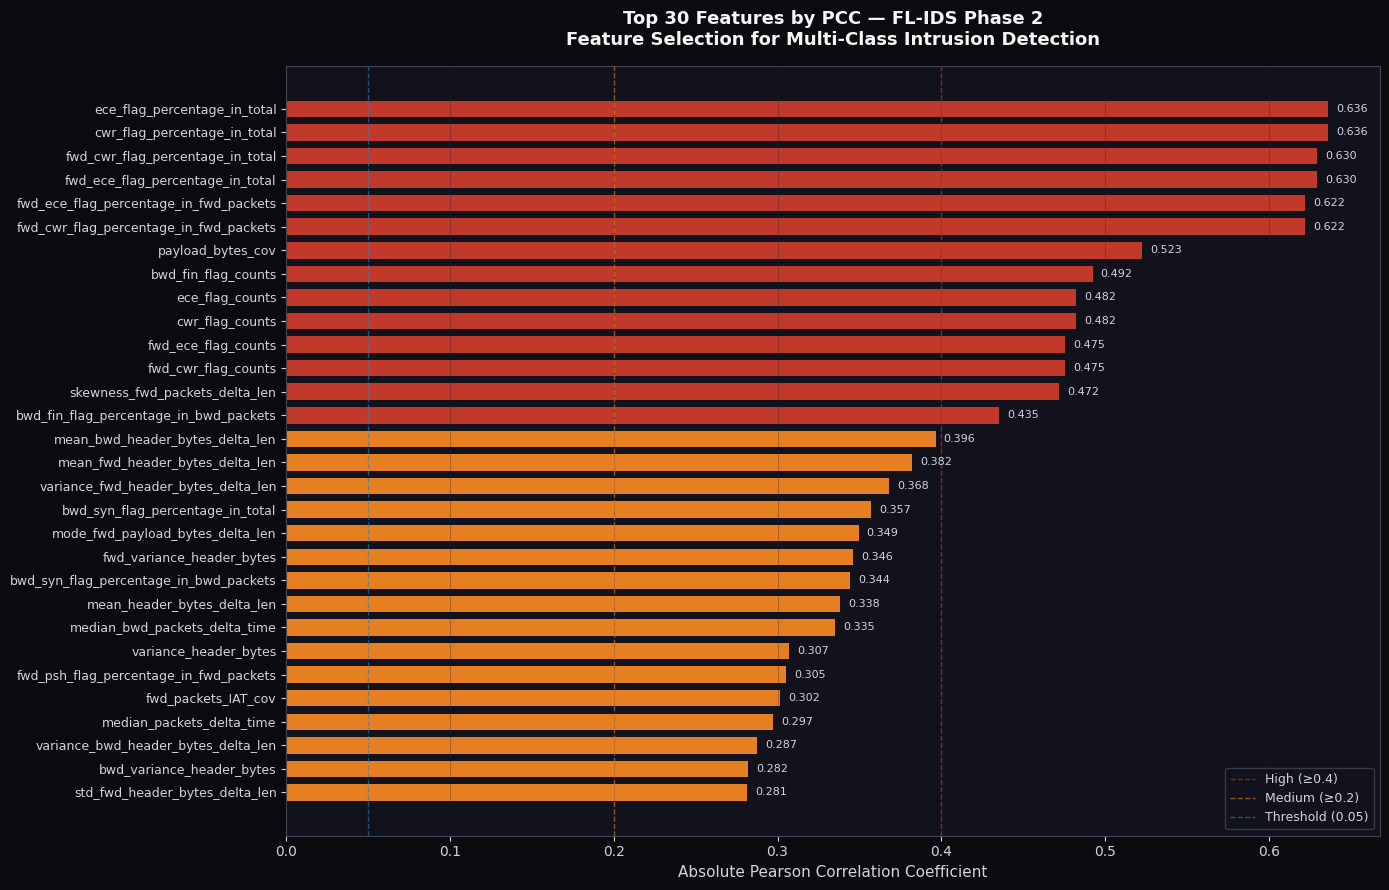

Saved → pcc_feature_importance.png


In [14]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.facecolor"] = "#0A0A0F"
matplotlib.rcParams["axes.facecolor"] = "#12121C"
matplotlib.rcParams["axes.edgecolor"] = "#444455"
matplotlib.rcParams["text.color"] = "#D0D3E0"
matplotlib.rcParams["axes.labelcolor"] = "#D0D3E0"
matplotlib.rcParams["xtick.color"] = "#D0D3E0"
matplotlib.rcParams["ytick.color"] = "#D0D3E0"
matplotlib.rcParams["grid.color"] = "#222233"

TOP_N = 30
top_features = pcc_series.head(TOP_N)

fig, ax = plt.subplots(figsize=(14, 9))

colors = ["#C0392B" if v >= 0.4 else "#E67E22" if v >= 0.2 else "#2980B9"
          for v in top_features.values]

bars = ax.barh(range(TOP_N), top_features.values, color=colors, edgecolor="none", height=0.7)

ax.set_yticks(range(TOP_N))
ax.set_yticklabels(top_features.index, fontsize=9)
ax.invert_yaxis()

ax.axvline(x=0.4, color="#C0392B", linestyle="--", linewidth=1, alpha=0.6, label="High (≥0.4)")
ax.axvline(x=0.2, color="#E67E22", linestyle="--", linewidth=1, alpha=0.6, label="Medium (≥0.2)")
ax.axvline(x=0.05, color="#2980B9", linestyle="--", linewidth=1, alpha=0.6, label="Threshold (0.05)")

for bar, val in zip(bars, top_features.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=8, color="#D0D3E0")

ax.set_xlabel("Absolute Pearson Correlation Coefficient", fontsize=11)
ax.set_title("Top 30 Features by PCC — FL-IDS Phase 2\nFeature Selection for Multi-Class Intrusion Detection",
             fontsize=13, fontweight="bold", color="#F5F5F5", pad=15)
ax.legend(loc="lower right", fontsize=9, facecolor="#12121C", edgecolor="#444455")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("../data_processed/pcc_feature_importance.png", dpi=150, bbox_inches="tight",
            facecolor="#0A0A0F")
plt.show()
print("Saved → pcc_feature_importance.png")

Cell 9 — Correlation Heatmap of Top 30 Features

Deep red blocks = features that are nearly identical to each other — keeping both adds no new information, one could be dropped

Deep blue blocks = features that move in opposite directions — both are useful because they capture different signals

White/yellow = no correlation — independent features, both worth keeping

The top-left cluster (ECE/CWR flags) will almost certainly be a deep red block — confirming they're redundant with each other despite both having high PCC vs label

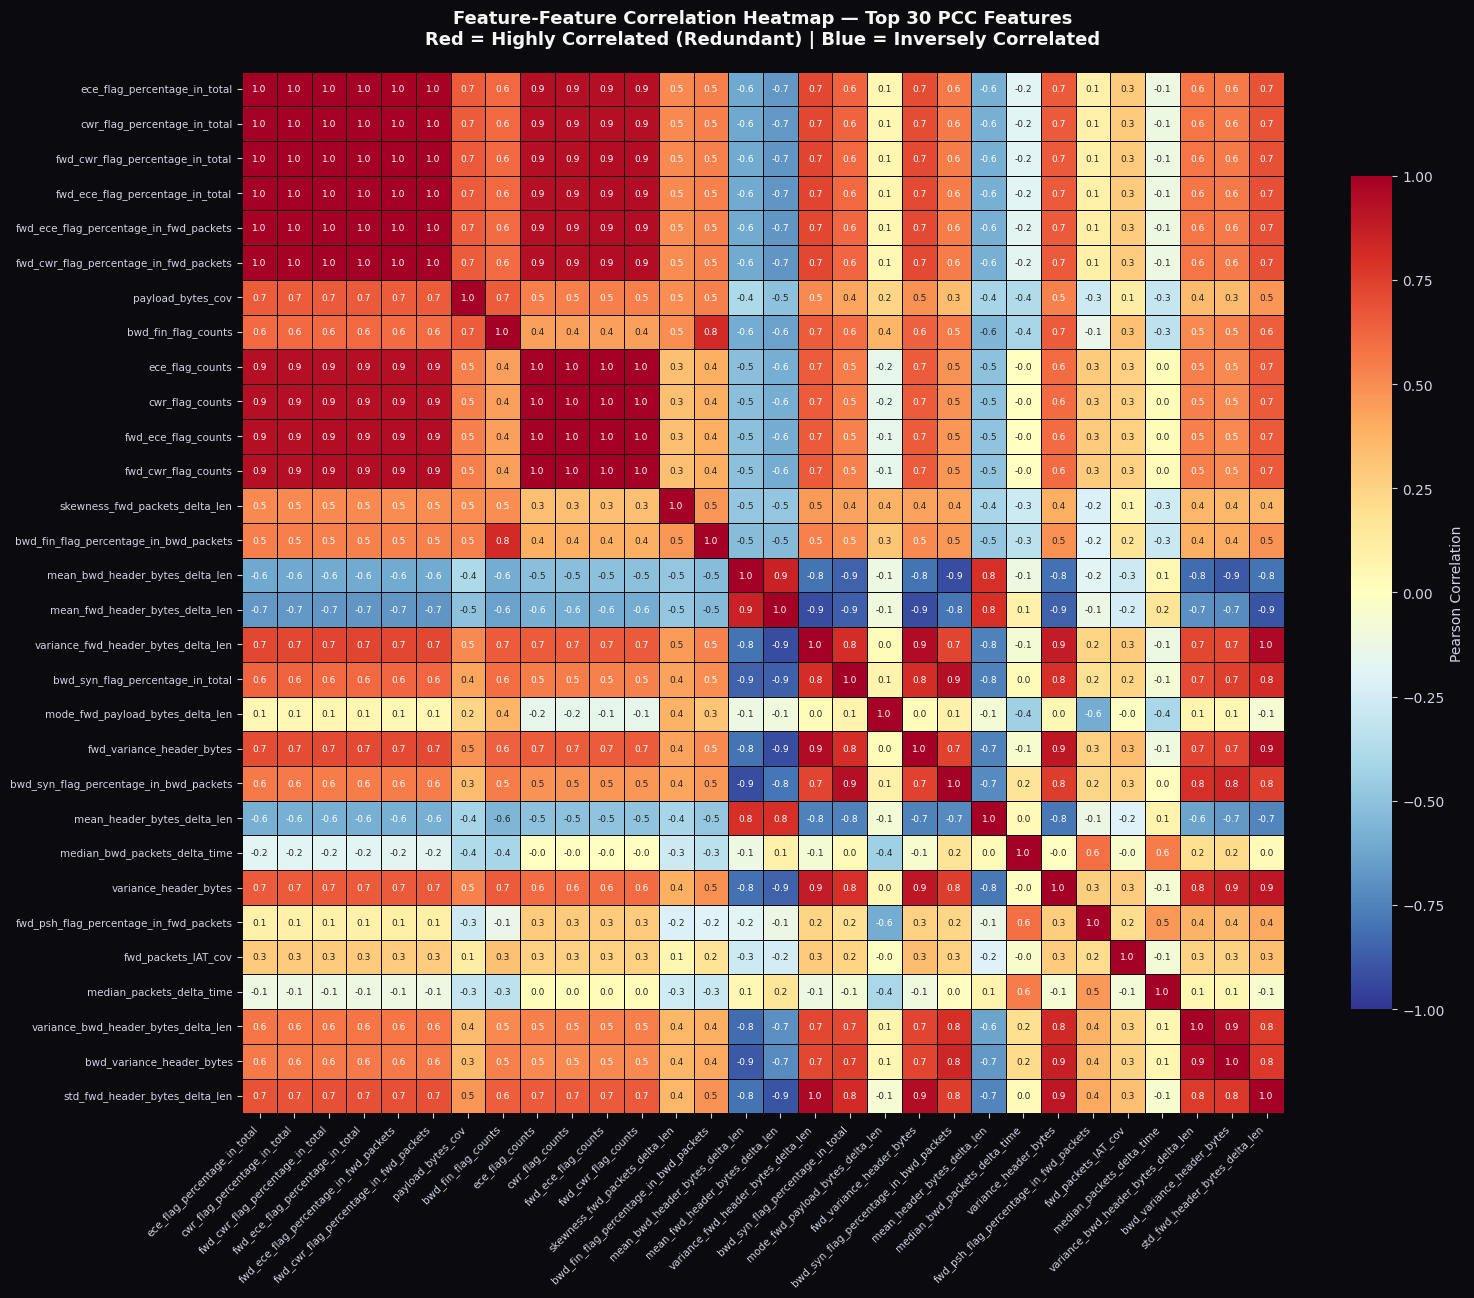

Saved → pcc_heatmap.png


In [15]:
import seaborn as sns

TOP_N = 30
top_cols = pcc_series.head(TOP_N).index.tolist()
corr_matrix = df[top_cols].corr()

fig, ax = plt.subplots(figsize=(16, 13))

sns.heatmap(
    corr_matrix,
    ax=ax,
    cmap="RdYlBu_r",
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt=".1f",
    annot_kws={"size": 6.5},
    linewidths=0.4,
    linecolor="#0A0A0F",
    square=True,
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation"}
)

ax.set_title(
    "Feature-Feature Correlation Heatmap — Top 30 PCC Features\n"
    "Red = Highly Correlated (Redundant) | Blue = Inversely Correlated",
    fontsize=13, fontweight="bold", color="#F5F5F5", pad=20
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=7.5)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7.5)

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_color("#D0D3E0")
cbar.ax.tick_params(colors="#D0D3E0")

plt.tight_layout()
plt.savefig("../data_processed/pcc_heatmap.png", dpi=150, bbox_inches="tight",
            facecolor="#0A0A0F")
plt.show()
print("Saved → pcc_heatmap.png")

Cell 10 — Remove Redundant Features (Correlation-based)

In [16]:
X_selected = df[selected_features].copy()
label_col = df["Label"].copy()

corr_matrix_full = X_selected.corr().abs()

upper_triangle = corr_matrix_full.where(
    np.triu(np.ones(corr_matrix_full.shape), k=1).astype(bool)
)

REDUNDANCY_THRESHOLD = 0.90
redundant_cols = [
    col for col in upper_triangle.columns
    if any(upper_triangle[col] >= REDUNDANCY_THRESHOLD)
]

print(f"Features before redundancy removal: {X_selected.shape[1]}")
print(f"Redundant features (corr ≥ {REDUNDANCY_THRESHOLD}): {len(redundant_cols)}")

X_selected.drop(columns=redundant_cols, inplace=True)

print(f"Features after redundancy removal:  {X_selected.shape[1]}")
print(f"\nSample of dropped redundant features:")
for f in redundant_cols[:10]:
    print(f"  ✗ {f}")

df_clean = X_selected.copy()
df_clean["Label"] = label_col.values

print(f"\nFinal dataset shape: {df_clean.shape}")
print(f"Features feeding into model: {df_clean.shape[1] - 1}")

Features before redundancy removal: 192
Redundant features (corr ≥ 0.9): 96
Features after redundancy removal:  96

Sample of dropped redundant features:
  ✗ cwr_flag_percentage_in_total
  ✗ fwd_cwr_flag_percentage_in_total
  ✗ fwd_ece_flag_percentage_in_total
  ✗ fwd_ece_flag_percentage_in_fwd_packets
  ✗ fwd_cwr_flag_percentage_in_fwd_packets
  ✗ ece_flag_counts
  ✗ cwr_flag_counts
  ✗ fwd_ece_flag_counts
  ✗ fwd_cwr_flag_counts
  ✗ variance_fwd_header_bytes_delta_len

Final dataset shape: (618214, 97)
Features feeding into model: 96


Cell 11 — Visualize Class Distribution Before SMOTE

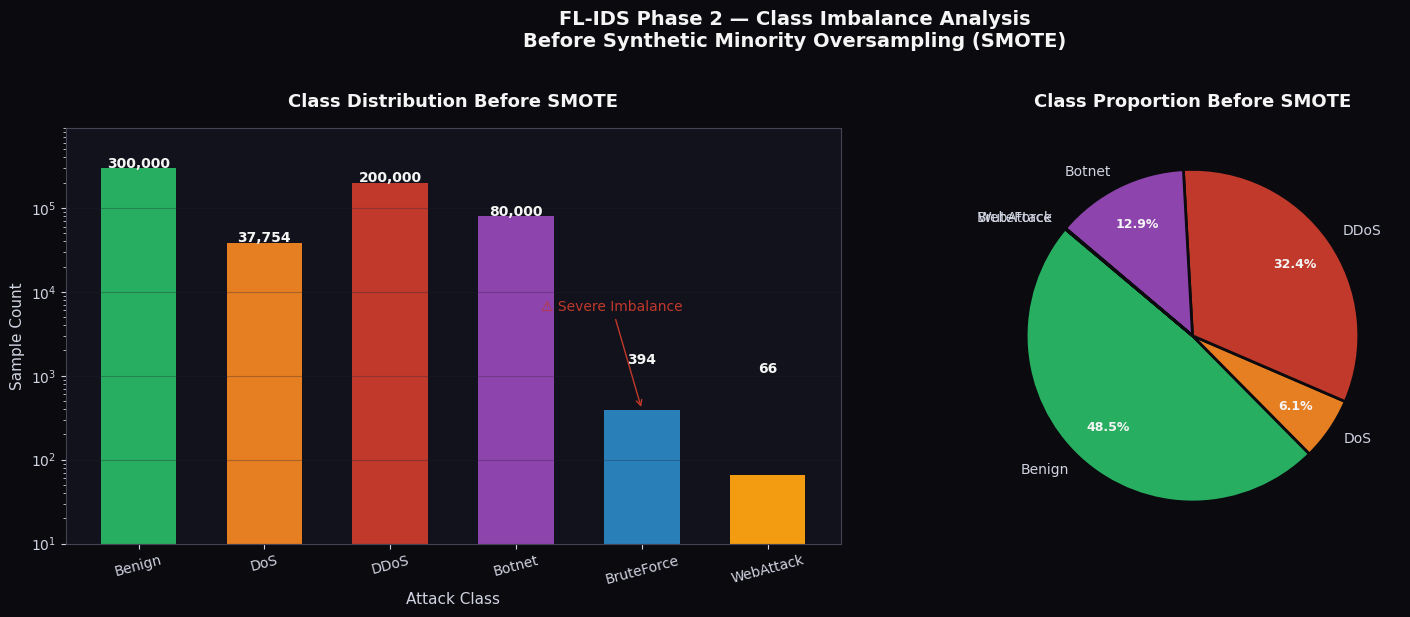

Saved → class_distribution_before_smote.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

class_names = ["Benign", "DoS", "DDoS", "Botnet", "BruteForce", "WebAttack"]
class_colors = ["#27AE60", "#E67E22", "#C0392B", "#8E44AD", "#2980B9", "#F39C12"]
counts = [df_clean[df_clean["Label"] == i].shape[0] for i in range(6)]

# Left — Bar chart
axes[0].bar(class_names, counts, color=class_colors, edgecolor="none", width=0.6)
for i, (name, count) in enumerate(zip(class_names, counts)):
    axes[0].text(i, count + 1000, f"{count:,}", ha="center", fontsize=10,
                 color="#F5F5F5", fontweight="bold")
axes[0].set_title("Class Distribution Before SMOTE", fontsize=13,
                  fontweight="bold", color="#F5F5F5", pad=15)
axes[0].set_xlabel("Attack Class", fontsize=11)
axes[0].set_ylabel("Sample Count", fontsize=11)
axes[0].set_yscale("log")
axes[0].set_ylim(10, max(counts) * 3)
axes[0].tick_params(axis="x", rotation=15)
axes[0].grid(axis="y", alpha=0.3)
axes[0].annotate("⚠ Severe Imbalance", xy=(4, counts[4]),
                 xytext=(3.2, counts[4] * 15),
                 arrowprops=dict(arrowstyle="->", color="#C0392B"),
                 fontsize=10, color="#C0392B")

# Right — Pie chart
wedge_props = {"linewidth": 2, "edgecolor": "#0A0A0F"}
wedges, texts, autotexts = axes[1].pie(
    counts, labels=class_names, colors=class_colors,
    autopct=lambda p: f"{p:.1f}%" if p > 1 else "",
    startangle=140, wedgeprops=wedge_props,
    pctdistance=0.75
)
for text in texts:
    text.set_color("#D0D3E0")
    text.set_fontsize(10)
for autotext in autotexts:
    autotext.set_color("#F5F5F5")
    autotext.set_fontsize(9)
    autotext.set_fontweight("bold")

axes[1].set_title("Class Proportion Before SMOTE", fontsize=13,
                  fontweight="bold", color="#F5F5F5", pad=15)

plt.suptitle("FL-IDS Phase 2 — Class Imbalance Analysis\nBefore Synthetic Minority Oversampling (SMOTE)",
             fontsize=14, fontweight="bold", color="#F5F5F5", y=1.02)

plt.tight_layout()
plt.savefig("../data_processed/class_distribution_before_smote.png",
            dpi=150, bbox_inches="tight", facecolor="#0A0A0F")
plt.show()
print("Saved → class_distribution_before_smote.png")

Cell 12 — SMOTE Oversampling

What's happening:

sampling_strategy dict gives us explicit control over final class sizes — we're not blindly equalizing everything

Benign stays largest (240K) since it dominates real traffic — equalizing it down would make the model unrealistic

DDoS stays second (160K) — it's genuinely the most common attack type

BruteForce and WebAttack both jump to 80K — synthetically generated but statistically valid

k_neighbors=5 — SMOTE generates each synthetic sample by interpolating between a real sample and its 5 nearest neighbors in feature space

n_jobs=-1 — uses all CPU cores to speed it up

In [19]:
import subprocess
subprocess.run(["pip", "install", "imbalanced-learn"], check=True)

CompletedProcess(args=['pip', 'install', 'imbalanced-learn'], returncode=0)

In [23]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

X_smote = df_clean.drop(columns=["Label"])
y_smote = df_clean["Label"]

# Step 1: SMOTE — only bring UP classes below 37754
over_strategy = {
    1: 37754,   # DoS already at 37754, skip
    4: 37754,   # BruteForce 394 → 37754
    5: 37754,   # WebAttack 66 → 37754
}

# Step 2: Undersample — bring DOWN classes above 37754
under_strategy = {
    0: 80000,   # Benign 300000 → 80000
    2: 80000,   # DDoS 200000 → 80000
    3: 80000,   # Botnet 80000 → stays
}

pipeline = Pipeline([
    ("smote", SMOTE(sampling_strategy=over_strategy, random_state=42, k_neighbors=5)),
    ("under", RandomUnderSampler(sampling_strategy=under_strategy, random_state=42))
])

print("Running SMOTE + Undersampling pipeline...")
X_resampled, y_resampled = pipeline.fit_resample(X_smote, y_smote)

print("\nClass counts after resampling:")
total = len(y_resampled)
for i, name in enumerate(class_names):
    count = (y_resampled == i).sum()
    pct = count / total * 100
    print(f"  Class {i} ({name:12s}): {count:>7,}  ({pct:.1f}%)")

print(f"\nFinal resampled shape: {X_resampled.shape}")

Running SMOTE + Undersampling pipeline...

Class counts after resampling:
  Class 0 (Benign      ):  80,000  (22.6%)
  Class 1 (DoS         ):  37,754  (10.7%)
  Class 2 (DDoS        ):  80,000  (22.6%)
  Class 3 (Botnet      ):  80,000  (22.6%)
  Class 4 (BruteForce  ):  37,754  (10.7%)
  Class 5 (WebAttack   ):  37,754  (10.7%)

Final resampled shape: (353262, 96)


Cell 13 — Visualize Class Distribution After SMOTE

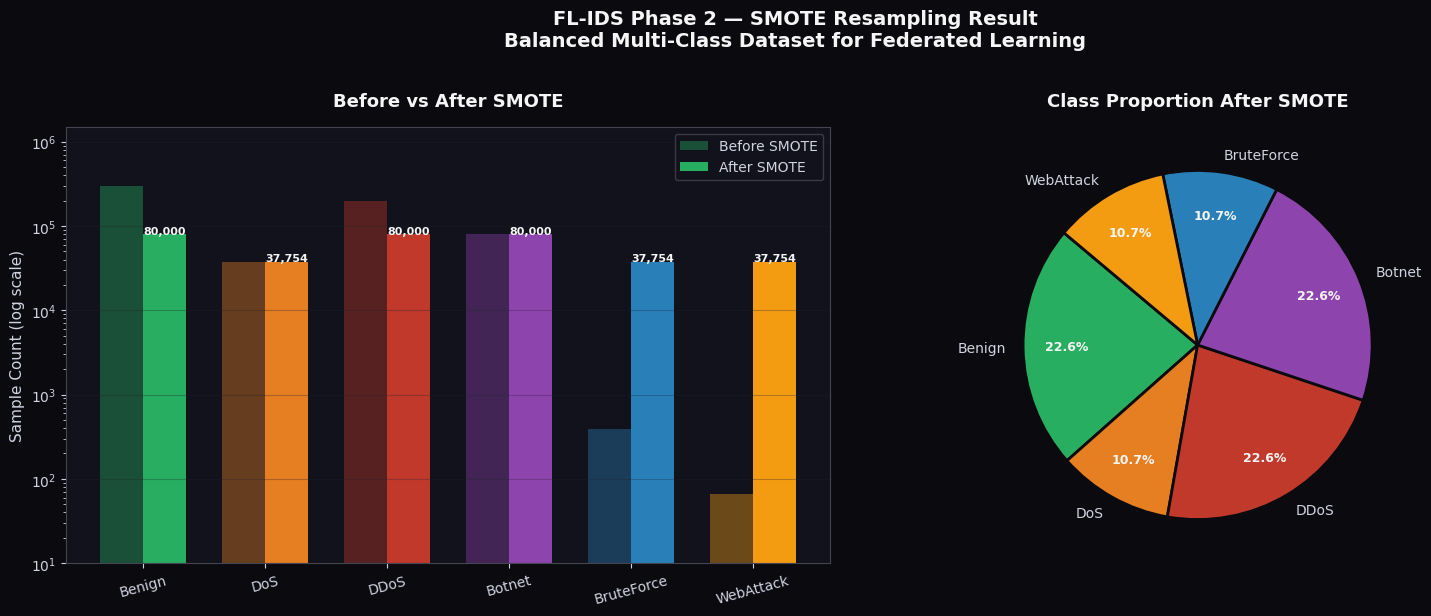

Saved → class_distribution_after_smote.png


In [24]:
counts_after = [(y_resampled == i).sum() for i in range(6)]
counts_before = [300000, 37754, 200000, 80000, 394, 66]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left — Before vs After grouped bar
x = np.arange(len(class_names))
width = 0.35

bars1 = axes[0].bar(x - width/2, counts_before, width, label="Before SMOTE",
                     color=class_colors, alpha=0.4, edgecolor="none")
bars2 = axes[0].bar(x + width/2, counts_after, width, label="After SMOTE",
                     color=class_colors, edgecolor="none")

for bar, val in zip(bars2, counts_after):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f"{val:,}", ha="center", fontsize=8, color="#F5F5F5", fontweight="bold")

axes[0].set_yscale("log")
axes[0].set_ylim(10, max(counts_before) * 5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(class_names, rotation=15, fontsize=10)
axes[0].set_title("Before vs After SMOTE", fontsize=13, fontweight="bold", color="#F5F5F5", pad=15)
axes[0].set_ylabel("Sample Count (log scale)", fontsize=11)
axes[0].legend(fontsize=10, facecolor="#12121C", edgecolor="#444455")
axes[0].grid(axis="y", alpha=0.3)

# Right — After SMOTE pie
wedge_props = {"linewidth": 2, "edgecolor": "#0A0A0F"}
wedges, texts, autotexts = axes[1].pie(
    counts_after, labels=class_names, colors=class_colors,
    autopct="%1.1f%%", startangle=140, wedgeprops=wedge_props,
    pctdistance=0.75
)
for text in texts:
    text.set_color("#D0D3E0")
    text.set_fontsize(10)
for autotext in autotexts:
    autotext.set_color("#F5F5F5")
    autotext.set_fontsize(9)
    autotext.set_fontweight("bold")

axes[1].set_title("Class Proportion After SMOTE", fontsize=13,
                  fontweight="bold", color="#F5F5F5", pad=15)

plt.suptitle("FL-IDS Phase 2 — SMOTE Resampling Result\nBalanced Multi-Class Dataset for Federated Learning",
             fontsize=14, fontweight="bold", color="#F5F5F5", y=1.02)

plt.tight_layout()
plt.savefig("../data_processed/class_distribution_after_smote.png",
            dpi=150, bbox_inches="tight", facecolor="#0A0A0F")
plt.show()
print("Saved → class_distribution_after_smote.png")

Cell 14 — Save Final Dataset + Train/Test Split

In [25]:
from sklearn.model_selection import train_test_split

df_final = pd.DataFrame(X_resampled, columns=df_clean.drop(columns=["Label"]).columns)
df_final["Label"] = y_resampled

print(f"Final dataset shape: {df_final.shape}")

X = df_final.drop(columns=["Label"]).values
y = df_final["Label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape}")
print(f"Test set:  {X_test.shape}")

print(f"\nTrain class distribution:")
for i, name in enumerate(class_names):
    count = (y_train == i).sum()
    print(f"  Class {i} ({name:12s}): {count:>7,}")

print(f"\nTest class distribution:")
for i, name in enumerate(class_names):
    count = (y_test == i).sum()
    print(f"  Class {i} ({name:12s}): {count:>7,}")

np.save("../data_processed/X_train_phase2.npy", X_train)
np.save("../data_processed/X_test_phase2.npy", X_test)
np.save("../data_processed/y_train_phase2.npy", y_train)
np.save("../data_processed/y_test_phase2.npy", y_test)

feature_names = df_clean.drop(columns=["Label"]).columns.tolist()
pd.Series(feature_names).to_csv("../data_processed/selected_features_phase2.csv", index=False)

print("\nSaved:")
print("  → X_train_phase2.npy")
print("  → X_test_phase2.npy")
print("  → y_train_phase2.npy")
print("  → y_test_phase2.npy")
print("  → selected_features_phase2.csv")

Final dataset shape: (353262, 97)

Train set: (282609, 96)
Test set:  (70653, 96)

Train class distribution:
  Class 0 (Benign      ):  64,000
  Class 1 (DoS         ):  30,203
  Class 2 (DDoS        ):  64,000
  Class 3 (Botnet      ):  64,000
  Class 4 (BruteForce  ):  30,203
  Class 5 (WebAttack   ):  30,203

Test class distribution:
  Class 0 (Benign      ):  16,000
  Class 1 (DoS         ):   7,551
  Class 2 (DDoS        ):  16,000
  Class 3 (Botnet      ):  16,000
  Class 4 (BruteForce  ):   7,551
  Class 5 (WebAttack   ):   7,551

Saved:
  → X_train_phase2.npy
  → X_test_phase2.npy
  → y_train_phase2.npy
  → y_test_phase2.npy
  → selected_features_phase2.csv


stratify=y — ensures train/test split maintains the same class proportions we worked hard to balance
80/20 split — 282K train, 70K test
Saving as .npy (NumPy binary) instead of CSV — loads 10x faster and uses less disk space
Feature names saved separately — needed later when we build the model input layer and for explainability
This is the checkpoint — if anything crashes later, we reload from these files instead of rerunning everything

Here's what we accomplished in this notebook:
Step                        Input                   Output
Load per-attack CSVs    6 raw files             618K rows, 318 cols
Clean Inf/NaN           618K dirty              618K clean
PCC selection           317 features            192 features
Redundancy removal      192 features            96 features
SMOTE + Undersample     Imbalanced 618K         Balanced 353K
Train/Test split        353K                    282K train / 70K test